In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import statsmodels.api as sm



from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [2]:
landhist_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CMIP6_land-hist/'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CMIP6_land-hist_pr-gini/'
fig_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/r1/'
flux_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/ukkola_flux/'

### Aggregation functions

In [38]:
#water-year transformations
def wyAgg(this_v_m_e_ds,op):
    this_v_m_e_monthly = this_v_m_e_ds
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    #print('computing NH water year P, ET, Q.', flush=True)
    nh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 10, this_v_m_e_ds.time.dt.year + 1)
    this_v_m_e_monthly['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 7, this_v_m_e_ds.time.dt.year + 1)
    this_v_m_e_monthly['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = this_v_m_e_monthly.lat>=0.0
    northern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = this_v_m_e_monthly.lat<0.0
    southern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[southern_hemi_latmask])

    # aggregate each hemisphere to its respective water-year level:
    print('computing hemispheres.', flush=True)
    if op == 'sum':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').sum(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').sum(dim='time')
    elif op == 'mean':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').mean(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').mean(dim='time')
    else:
        print('not a valid operation')
        
    # merge north and southern hemispheres together into one water-year dataset:
    print('merging hemispheres.', flush=True)

    this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'})
    this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'})

    this_v_m_e_wateryear_sum = xr.merge([this_v_m_e_nhwy_sum, this_v_m_e_shwy_sum],compat='override')
    this_v_m_e_wateryear_sum = this_v_m_e_wateryear_sum
    
    return this_v_m_e_wateryear_sum

def getHemiWY(ds):
    
    ds_wy = ds
    
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 10, ds.time.dt.year + 1)
    ds_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 7, ds.time.dt.year + 1)
    ds_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = ds_wy.lat>=0.0
    northern_hemi = ds_wy.sel(lat=ds_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = ds_wy.lat<0.0
    southern_hemi = ds_wy.sel(lat=ds_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask



In [4]:
def gini(x):
    # computes unweighted gini index on a vector
    # from: https://stackoverflow.com/questions/48999542/more-efficient-weighted-gini-coefficient-in-python
    # equivalent to (np.sum((2 * index - n  - 1) * x)) / (n * np.sum(x)), which is more common notation but slower
    
    n = len(x)
    
    # if obs missing, drop
    x[np.isnan(x)] = np.median(x)
    
    cumx = np.cumsum(x, dtype=float)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

In [5]:
def pexqMerge(ds,varname,dfname,detrend=True,regrid=True,stdz=True):
    
    if detrend:
        print('detrending')
        dsdetrend = detrend_dim(ds[varname])
    else:
        dsdetrend = ds[varname]
        
    mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
    mask = mask.interp_like(ds)
    mask = mask.landseamask < 75
    dsdetrend = dsdetrend.where(mask)
    
    #interp to reference grid:
    if regrid:
        print('regridding')
        refgrd = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')
        dsdetrend = dsdetrend.interp_like(refgrd.sel(water_year=refgrd.water_year[0]))
    
    ds_mask = dsdetrend.sel(lat=slice(-55,70))        
    
    #to df
    ds_mask_df = ds_mask.to_dataframe(name=dfname)

    # drop masked rows
    ds_mask_df = ds_mask_df.dropna()
    ds_mask_df = ds_mask_df.reset_index()

    # add unique grid id
    indices = [ds_mask_df.loc[ind].lat.astype('str')+'_'
               +ds_mask_df.loc[ind].lon.astype('str') for ind in ds_mask_df.index]
    ds_mask_df['gridindex'] = indices

    # also stdize anomalies
    if stdz:
        print('standardizing')
        ds_SD = ds_mask.std(dim='water_year')
        ds_stdz = ds_mask/ds_SD

        #to df
        ds_stdz_df = ds_stdz.to_dataframe(name=dfname)
        ds_stdz_df = ds_stdz_df.reset_index()

        # drop masked rows
        ds_stdz_df = ds_stdz_df.dropna()

        # add unique grid id
        indices = [ds_mask_df.loc[ind].lat.astype('str')+'_'
                   +ds_mask_df.loc[ind].lon.astype('str') for ind in ds_mask_df.index]
        ds_stdz_df['gridindex'] = indices
        
    else:
        ds_stdz_df = []
        
    return ds_mask_df,ds_stdz_df

# wrap linear detrend
def detrend_dim(da, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim='water_year', deg=deg)
    fit = xr.polyval(da.water_year, p.polyfit_coefficients)
    return da - fit

In [6]:
def kgm2s1_to_mmpermonth(data,varname):
    """ 
    This function converts a dataset from kg m-2 s-1 to mm per month.
    Maybe doesn't need its own function but I think it could be helpful in the future
    when downsampling other var's.
    
    Params:
    -------
        data (xr.dataset) Must have a time dimension. MAKE SURE UNITS ARE KG (WATER) M-2 S-1.
        
    Returns:
    --------
        data (xr.dataset) same data just w/ the datavar multiplied by 86400 and num of days per month.
        
    """
    
    print('converting to mm per month...')
    
    # get days per month
    days_in_month = data.time.dt.days_in_month
    
    # grabbing the name of this dataset's
    # that way user doesn't have to supply var name as an arg
    datavarname = varname

    # save old attrs
    old_var_attrs = data[datavarname].attrs
    
    # get mm per day:
    mmperday = data[datavarname] * 86400
    # mm per month
    mmpermonth = mmperday #* days_in_month
    
    # save that back into the data variable
    data[datavarname] = mmpermonth
    
    # add back on attrs...
    data[datavarname].attrs = old_var_attrs
    # ...but change units.
    data[datavarname].attrs['units'] = 'mm per month'
    
    # return that dataset
    return data

# aggregate to water-year
def resampleWY(data,varname,op='sum',units='mm per water-year',mass=True):
    
    time = 'wateryear'

    
    if mass:
        this_v_m_e_monthly = kgm2s1_to_mmpermonth(data,varname)
    else:
        this_v_m_e_monthly = data


    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    #print('computing NH water year P, ET, Q.', flush=True)
    nh_wateryears = data.time.dt.year.where(data.time.dt.month < 10, data.time.dt.year + 1)
    this_v_m_e_monthly['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = data.time.dt.year.where(data.time.dt.month < 7, data.time.dt.year + 1)
    this_v_m_e_monthly['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = this_v_m_e_monthly.lat>=0.0
    northern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = this_v_m_e_monthly.lat<0.0
    southern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[southern_hemi_latmask])

    # aggregate each hemisphere to its respective water-year level:
    print('computing hemispheres.', flush=True)
    
    if op == 'sum':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').sum(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').sum(dim='time')

    elif op == 'mean':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').mean(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').mean(dim='time')
        
    # merge north and southern hemispheres together into one water-year dataset:
    print('merging hemispheres.', flush=True)
    
    this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'})#.drop(['time_bounds'])#.drop(['lat_bnds','lon_bnds'])
    this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'})#.drop(['time_bounds'])#.drop(['lat_bnds','lon_bnds'])
#     elif ('bnds' in data.dims):
#         print('2')
#         this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'}).drop(['bnds','lat_bnds','lon_bnds'])
#         this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'}).drop(['bnds','lat_bnds','lon_bnds'])    
#     else:
#         print('3')
#         this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'}).drop(['lat_bnds','lon_bnds'])
#         this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'}).drop(['lat_bnds','lon_bnds'])
        
    this_v_m_e_wateryear_sum = xr.merge([this_v_m_e_nhwy_sum, this_v_m_e_shwy_sum])
    this_v_m_e_wateryear_sum = this_v_m_e_wateryear_sum.drop(['water_year_sh', 'water_year_nh'])

    # add attrs
    this_v_m_e_wateryear_sum.attrs['description'] = 'water-year mean pr'
    this_v_m_e_wateryear_sum.attrs['model'] = 'MIROC6'
    this_v_m_e_wateryear_sum.attrs['units'] = 'mm per water-year'


    
    return this_v_m_e_wateryear_sum

In [7]:
# river basin geom functions
def flipLon(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = (dsshift.lon.values + 180) % 360 - 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

def transform_from_latlon(lat, lon):
    lat = np.asarray(lat)
    lon = np.asarray(lon)
    trans = Affine.translation(lon[0], lat[0])
    scale = Affine.scale(lon[1] - lon[0], lat[1] - lat[0])
    return trans * scale

def flipLon360(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

import rasterio.features as features 

def rasterz(shapes, coords, fill=np.nan, **kwargs):
    """Rasterize a list of (geometry, fill_value) tuples onto the given
    xarray coordinates. This only works for 1d latitude and longitude
    arrays.
    """
    transform = transform_from_latlon(coords['lat'], coords['lon'])
    out_shape = (len(coords['lat']), len(coords['lon']))
    raster = features.rasterize(shapes, out_shape=out_shape,
                                fill=fill, transform=transform,
                                dtype=float, **kwargs)
    return xr.DataArray(raster, coords=coords, dims=('lat', 'lon'))


### calculate pr gini for MIROC6

In [73]:
### open MIROC6 land-hist pr
pr_ds = xr.open_mfdataset(landhist_dir + 'pr*.nc')

In [17]:

#compute water year gini
startyear = 1960
endyear = 2015

# split northern and southern hemis, set water year coord
nh,sh,nhmask,shmask = getHemiWY(ds)
gini_hold = []

for i,yr in enumerate(range(startyear,endyear+1)):
    print(yr)
    #subset time
    nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])
    #sort
    nhyr_sorted = np.sort(nhyr.pr.values,axis=0)
    shyr_sorted = np.sort(shyr.pr.values,axis=0)
    #apply gini
    nhgini = np.apply_along_axis(gini,0,nhyr_sorted)
    shgini = np.apply_along_axis(gini,0,shyr_sorted)
    #combine and store
    nhgds = xr.DataArray(nhgini,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shgds = xr.DataArray(shgini,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhgds = nhgds.to_dataset(name='Pgini_wy')
    shgds = shgds.to_dataset(name='Pgini_wy')
    gini_hold.append(xr.merge([nhgds,shgds]).Pgini_wy)

# to dataset
pr_gini_wy = xr.concat(gini_hold,dim='water_year')
pr_gini_wy = pr_gini_wy.assign_coords({'water_year':np.arange(startyear,endyear+1)})

pr_gini_wy.assign_attrs({'model':'MIROC6',
                   'index':'water-year daily rainfall gini coefficient, ' + str(startyear) + '-' + str(endyear)})


1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015


<xarray.DataArray 'Pgini_wy' (water_year: 56, lat: 128, lon: 256)>
array([[[0.65753428, 0.65753428, 0.65753428, ..., 0.66080341,
         0.66080341, 0.66080341],
        [0.6736313 , 0.6736313 , 0.6736313 , ..., 0.69690255,
         0.69690255, 0.69690255],
        [0.69572966, 0.69572966, 0.69572966, ..., 0.72431514,
         0.72431514, 0.72431514],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.66889598, 0.66889598, 0.66889598, ..., 0.67841487,
         0.67841487, 0.67841487],
        [0.69633935, 0.69633935, 0.69633935, ..., 0.70251559,
         0.70251559, 0.70251559],
        [0.70040935, 0.70040935, 0.70040935, ..., 0.71882802,
         0.71882802, 0.71882802],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.6515573 , 0.6515573 , 0.6515573 , ..., 0.65264108,
         0.65264108, 0.65264108],
        [0.62483266, 0.62483266, 0.62483266, ..., 0.6239117 ,
         0.6239117 , 0.6239117 ],
        [0.64963871, 0.64963871, 0.64963871, ..., 0.63993897,
         0.63993897, 0.63993897],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * lat         (lat) float64 -88.93 -87.54 -86.14 -84.74 ... 86.14 87.54 88.93
  * lon         (lon) float64 0.0 1.406 2.812 4.219 ... 354.4 355.8 357.2 358.6
  * water_year  (water_year) int64 1960 1961 1962 1963 ... 2012 2013 2014 2015
Attributes:
    model:    MIROC6
    index:    water-year daily rainfall gini coefficient, 1960-2015

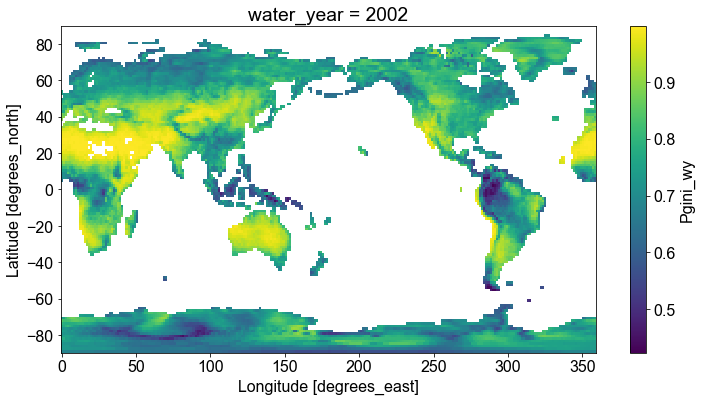

In [25]:
pr_gini_wy.sel(water_year=2002).plot()

In [26]:
#save
pr_gini_wy.to_netcdf(save_dir+'pr_day_gini_MIROC6_land-hist_1960-2014.nc')

### calculate water-year mean TWS, temperature and total precip, and climatological mean P

In [74]:
# daily pr -> wy
#resample to monthly and agg to wy
prwy = resampleWY(pr_ds,'pr',mass=True)


converting to mm per month...
computing hemispheres.
merging hemispheres.


In [85]:
# climatological mean P
repdim = prwy.water_year.shape[0]
prmhld = np.repeat(prwy.mean(dim='water_year').pr.values[:, :, np.newaxis], repdim, axis=2)
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy.lat,'lon':prwy.lon,
                                           'water_year':np.arange(prwy.water_year.min().values,
                                                                  prwy.water_year.max().values+1)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')


In [94]:
#water-year mean tas
tas_ds = xr.open_mfdataset(landhist_dir + 'tas*.nc')

In [96]:
twy = resampleWY(tas_ds,'tas',op='mean',mass=False,units='degrees C')

computing hemispheres.
merging hemispheres.


In [112]:
tws_ds = xr.open_mfdataset(landhist_dir + 'mrtws*.nc')

In [114]:
tws = resampleWY(tws_ds,'mrtws',op='mean',mass=False,units='mm')

computing hemispheres.
merging hemispheres.


### merge into df panel for regression

In [103]:
# trim twy to 1960-2014 and convert to C
twy = twy.sel(water_year=np.arange(1960,2016))
twy = twy-273.15

In [109]:
pr_gini_wy = pr_gini_wy.to_dataset(name='Pgini_wy')

In [111]:
# send precip vars to df: detrend, regrid, etc.
gp_df,gp_std = pexqMerge(pr_gini_wy,'Pgini_wy','Gp')
prwy_df,prwy_std_df = pexqMerge(prwy,'pr','P')
meanP_df,notdata = pexqMerge(prwy_mean_ds,'pr_mean','Pmean',detrend=False)

detrending
regridding
standardizing
detrending
regridding
standardizing
regridding
standardizing


In [119]:
# now do temp and tws
t_df,t_std = pexqMerge(twy,'tas','T')
tws_df,tws_std = pexqMerge(tws,'mrtws','TWS')


detrending
regridding
standardizing
detrending
regridding
standardizing


,water_year,lat,lon,TWS,gridindex
0,1960,-54.75,291.25,-19.102147,-54.75_291.25
1,1960,-54.75,291.75,-31.959394,-54.75_291.75
2,1960,-54.75,292.25,-44.816641,-54.75_292.25
3,1960,-54.25,291.25,-38.658372,-54.25_291.25
4,1960,-54.25,291.75,-61.822707,-54.25_291.75
...,...,...,...,...,...
2728763,2015,69.75,332.25,-7.945212,69.75_332.25
2728764,2015,69.75,332.75,8.393990,69.75_332.75
2728765,2015,69.75,333.25,24.733191,69.75_333.25
2728766,2015,69.75,333.75,20.850731,69.75_333.75


In [122]:
# create year-grid index to merge on for all variables
data_to_index = [gp_df,gp_std,prwy_df,prwy_std_df,meanP_df,t_df,t_std,tws_df,tws_std]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype(str) + '_' + d['gridindex'].astype(str)


In [124]:
#merge unstandardized
#merged_df = pexq_df.merge(gp_df[['yeargrid','Gp']], on='yeargrid', how='outer')
merged_df = gp_df.merge(meanP_df[['yeargrid','Pmean']], on='yeargrid', how='outer')
merged_df = merged_df.merge(prwy_df[['yeargrid','P']],on='yeargrid', how='outer')
merged_df = merged_df.merge(t_df[['yeargrid','T']],on='yeargrid', how='outer')
merged_df = merged_df.merge(tws_df[['yeargrid','TWS']],on='yeargrid', how='outer')

merged_df = merged_df.dropna()


### add GRDC basin id's

In [131]:
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')
#hshd = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/hydrosheds/hybas_au_lev01_v1c.shp')
#usgs = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/USGS_WBD/WBDHU2/WBDHU2.shp')

In [140]:

cmipgeom = flipLon(pr_ds.sel(time=pr_ds.time[0]).pr)
shapes = ((geom, 1) for geom in grdc_basins.geometry)
lons = cmipgeom.lon
lats = cmipgeom.lat

x_min, y_min, x_max, y_max = grdc_basins.total_bounds  
grid_resolution = 0.25
transform = transform_from_latlon(pr_ds.lon,pr_ds.lat)

# dictionary mapping river basin names onto integer IDs
basin_ids = dict(zip(grdc_basins["RIVER_BASI"],grdc_basins["MRBID"]))
basin_ids_rev = {v:k for k,v in basin_ids.items()}

# tuples mapping basin geometries onto those same IDs
basin_shapes = list(zip(grdc_basins["geometry"],grdc_basins["MRBID"].astype(int)))

basin_da = rasterz(basin_shapes,coords=dict(lat=lats,lon=lons))

basin_da = flipLon360(basin_da)


In [144]:
basin_ids = basin_da.sel(
    lat=xr.DataArray(merged_df['lat'].values, dims='points'),
    lon=xr.DataArray(merged_df['lon'].values, dims='points'),
    method='nearest'
    
).values

# Add the basin_ids as a new column to the DataFrame
merged_df['basin_id'] = basin_ids

In [152]:
merged_df.to_csv(save_dir+'pexq_df_MIROC6.csv')

### now assemble panel for CNRM
only 2 CMIP6 models have all required variables reported to ESGF for land-hist experiment

In [8]:
### open CNRM land-hist pr
pr_ds = xr.open_mfdataset(landhist_dir + 'pr_day_CNRM*.nc')

In [8]:

#compute water year gini
startyear = 1960
endyear = 2015

# split northern and southern hemis, set water year coord
nh,sh,nhmask,shmask = getHemiWY(pr_ds)
gini_hold = []

for i,yr in enumerate(range(startyear,endyear+1)):
    print(yr)
    #subset time
    nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])
    #sort
    nhyr_sorted = np.sort(nhyr.pr.values,axis=0)
    shyr_sorted = np.sort(shyr.pr.values,axis=0)
    #apply gini
    nhgini = np.apply_along_axis(gini,0,nhyr_sorted)
    shgini = np.apply_along_axis(gini,0,shyr_sorted)
    #combine and store
    nhgds = xr.DataArray(nhgini,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shgds = xr.DataArray(shgini,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhgds = nhgds.to_dataset(name='Pgini_wy')
    shgds = shgds.to_dataset(name='Pgini_wy')
    gini_hold.append(xr.merge([nhgds,shgds]).Pgini_wy)

# to dataset
pr_gini_wy = xr.concat(gini_hold,dim='water_year')
pr_gini_wy = pr_gini_wy.assign_coords({'water_year':np.arange(startyear,endyear+1)})

pr_gini_wy.assign_attrs({'model':'CNRM-CM6-1',
                   'index':'water-year daily rainfall gini coefficient, ' + str(startyear) + '-' + str(endyear)})


1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015


<xarray.DataArray 'Pgini_wy' (water_year: 56, lat: 128, lon: 256)>
array([[[0.62797219, 0.62797219, 0.62797219, ..., 0.62797219,
         0.62797219, 0.62797219],
        [0.68050385, 0.68050385, 0.68050385, ..., 0.68050385,
         0.68050385, 0.68050385],
        [0.70473663, 0.70473663, 0.70473663, ..., 0.69756106,
         0.70473663, 0.70473663],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.65363659, 0.65363659, 0.65363659, ..., 0.65363659,
         0.65363659, 0.65363659],
        [0.70105041, 0.70105041, 0.70105041, ..., 0.70105041,
         0.70105041, 0.70105041],
        [0.70227193, 0.70227193, 0.70227193, ..., 0.69938003,
         0.70227193, 0.70227193],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.67053307, 0.67053307, 0.67053307, ..., 0.67053307,
         0.67053307, 0.67053307],
        [0.63262665, 0.63262665, 0.63262665, ..., 0.63262665,
         0.63262665, 0.63262665],
        [0.65341172, 0.65341172, 0.65341172, ..., 0.63173348,
         0.65341172, 0.65341172],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]])
Coordinates:
  * lat         (lat) float64 -88.93 -87.54 -86.14 -84.74 ... 86.14 87.54 88.93
  * lon         (lon) float64 0.0 1.406 2.812 4.219 ... 354.4 355.8 357.2 358.6
  * water_year  (water_year) int64 1960 1961 1962 1963 ... 2012 2013 2014 2015
Attributes:
    model:    CNRM-CM6-1
    index:    water-year daily rainfall gini coefficient, 1960-2015

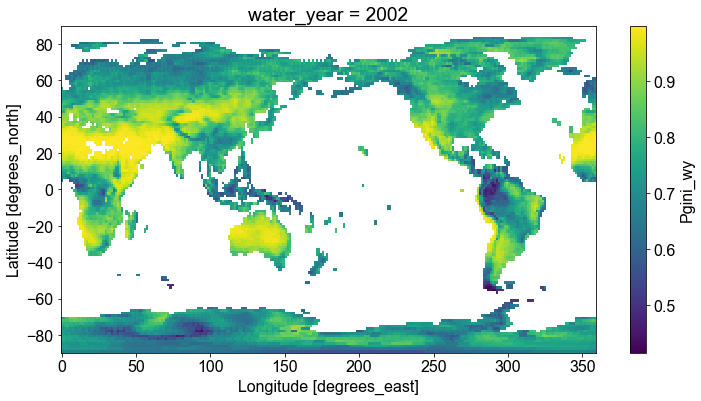

In [11]:
#plot to check that data looks right
pr_gini_wy.sel(water_year=2002).plot()


In [12]:
#save gini
pr_gini_wy.to_netcdf(save_dir+'pr_day_gini_CNRM-CM6-1_land-hist_1960-2014.nc')

In [12]:
# daily pr -> wy
#resample to monthly and agg to wy
prwy = resampleWY(pr_ds,'pr',mass=True)


converting to mm per month...
computing hemispheres.
merging hemispheres.


In [17]:
# climatological mean P
repdim = prwy.water_year.shape[0]
prmhld = np.repeat(prwy.mean(dim='water_year').pr.values[:, :, np.newaxis], repdim, axis=2)
prwy_mean_ds = xr.DataArray(prmhld,coords={'lat':prwy.lat,'lon':prwy.lon,
                                           'water_year':np.arange(prwy.water_year.min().values,
                                                                  prwy.water_year.max().values+1)})
prwy_mean_ds = prwy_mean_ds.to_dataset(name='pr_mean')


In [20]:
#water-year mean tas

# CNRM reports tmax and tmin : average to get tas (daily mean)  
tasmax_ds = xr.open_mfdataset(landhist_dir + 'tasmax*.nc')
tasmin_ds = xr.open_mfdataset(landhist_dir + 'tasmin*.nc')

tas_ds = (tasmin_ds["tasmin"] + tasmax_ds["tasmax"]) / 2

# Optional: Put it into a new Dataset
tas_ds = tas_ds.to_dataset(name="tas")

In [21]:
twy = resampleWY(tas_ds,'tas',op='mean',mass=False,units='degrees C')

computing hemispheres.
merging hemispheres.


In [22]:
tws_ds = xr.open_mfdataset(landhist_dir + 'mrtws_Eday_CNRM*.nc')

In [23]:
tws = resampleWY(tws_ds,'mrtws',op='mean',mass=False,units='mm')

computing hemispheres.
merging hemispheres.


### merge into df panel for regression

In [26]:
#load gini
pr_gini_wy = xr.open_dataset(save_dir+'pr_day_gini_CNRM-CM6-1_land-hist_1960-2014.nc')

In [24]:
# trim twy to 1960-2014 and convert to C
twy = twy.sel(water_year=np.arange(1960,2016))
twy = twy-273.15

In [29]:
# send precip vars to df: detrend, regrid, etc.
gp_df,gp_std = pexqMerge(pr_gini_wy,'Pgini_wy','Gp')
prwy_df,prwy_std_df = pexqMerge(prwy,'pr','P')
meanP_df,notdata = pexqMerge(prwy_mean_ds,'pr_mean','Pmean',detrend=False)

detrending
regridding
standardizing
detrending
regridding
standardizing
regridding
standardizing


In [ ]:
# now do temp and tws
t_df,t_std = pexqMerge(twy,'tas','T')



detrending
regridding


In [36]:
tws = tws.sel(water_year=np.arange(1960,2016))
tws_df,tws_std = pexqMerge(tws,'mrtws','TWS')

detrending
regridding
standardizing


In [39]:
# create year-grid index to merge on for all variables
data_to_index = [gp_df,gp_std,prwy_df,prwy_std_df,meanP_df,t_df,t_std,tws_df,tws_std]
for d in data_to_index:
    d['yeargrid'] = d['water_year'].astype(str) + '_' + d['gridindex'].astype(str)


In [40]:
#merge unstandardized
#merged_df = pexq_df.merge(gp_df[['yeargrid','Gp']], on='yeargrid', how='outer')
merged_df = gp_df.merge(meanP_df[['yeargrid','Pmean']], on='yeargrid', how='outer')
merged_df = merged_df.merge(prwy_df[['yeargrid','P']],on='yeargrid', how='outer')
merged_df = merged_df.merge(t_df[['yeargrid','T']],on='yeargrid', how='outer')
merged_df = merged_df.merge(tws_df[['yeargrid','TWS']],on='yeargrid', how='outer')

merged_df = merged_df.dropna()


In [41]:
# set up basin id raster
grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')

cmipgeom = flipLon(pr_ds.sel(time=pr_ds.time[0]).pr)
shapes = ((geom, 1) for geom in grdc_basins.geometry)
lons = cmipgeom.lon
lats = cmipgeom.lat

x_min, y_min, x_max, y_max = grdc_basins.total_bounds  
grid_resolution = 0.25
transform = transform_from_latlon(pr_ds.lon,pr_ds.lat)

# dictionary mapping river basin names onto integer IDs
basin_ids = dict(zip(grdc_basins["RIVER_BASI"],grdc_basins["MRBID"]))
basin_ids_rev = {v:k for k,v in basin_ids.items()}

# tuples mapping basin geometries onto those same IDs
basin_shapes = list(zip(grdc_basins["geometry"],grdc_basins["MRBID"].astype(int)))

basin_da = rasterz(basin_shapes,coords=dict(lat=lats,lon=lons))

basin_da = flipLon360(basin_da)


In [42]:
# grab basin id's for each panel data point
basin_ids = basin_da.sel(
    lat=xr.DataArray(merged_df['lat'].values, dims='points'),
    lon=xr.DataArray(merged_df['lon'].values, dims='points'),
    method='nearest'
).values

# Add the basin_ids as a new column to the DataFrame
merged_df['basin_id'] = basin_ids

In [43]:
merged_df

,water_year,lat,lon,Gp,gridindex,yeargrid,Pmean,P,T,TWS,basin_id
0,1960.0,-54.75,291.25,-0.019891,-54.75_291.25,1960_-54.75_291.25,686.990047,20.791457,0.015753,-6.402646,NaN
1,1960.0,-54.75,291.75,-0.016833,-54.75_291.75,1960_-54.75_291.75,656.158889,10.949061,-0.045748,-6.211161,NaN
2,1960.0,-54.75,292.25,-0.013775,-54.75_292.25,1960_-54.75_292.25,625.327731,1.106665,-0.107249,-6.019676,NaN
3,1960.0,-54.25,291.25,-0.020137,-54.25_291.25,1960_-54.25_291.25,604.837379,-27.448228,0.061857,-9.363585,NaN
4,1960.0,-54.25,291.75,-0.012753,-54.25_291.75,1960_-54.25_291.75,588.782292,-34.647948,0.000820,-10.921054,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2707801,2015.0,69.75,332.25,-0.052609,69.75_332.25,2015_69.75_332.25,917.398214,-609.980980,-2.266969,217.435798,NaN
2707802,2015.0,69.75,332.75,-0.053920,69.75_332.75,2015_69.75_332.75,887.006643,-562.849094,-2.173957,173.170828,NaN
2707803,2015.0,69.75,333.25,-0.055232,69.75_333.25,2015_69.75_333.25,856.615072,-515.717207,-2.080946,128.905858,NaN
2707804,2015.0,69.75,333.75,-0.057978,69.75_333.75,2015_69.75_333.75,806.998660,-454.323235,-2.018280,77.539153,NaN


In [44]:
merged_df.to_csv(save_dir+'pexq_df_CNRM-CM6-1.csv')

### from here, panel goes to R for FELM regression, then plot

In [45]:
load_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'

In [46]:
# load absolute regression coefficients
cpc_results = pd.read_csv(load_dir+'reg_results/CPC_regression_results.csv')
gpcp_results = pd.read_csv(load_dir+'reg_results/GPCP_regression_results.csv')
gpcc_results = pd.read_csv(load_dir+'reg_results/GPCC_regression_results.csv')

In [47]:
###  calculate conditional marginal effect +/- SE
scale = 0.1 # per 0.1 gp
scale = scale*10
n_se = 2

#conditional coef estimates
gamma_abs = cpc_results['coef_Gp'][0]
chi_abs = cpc_results['coef_GpP'][0]
gamma_se = cpc_results['se_Gp'][0]
chi_se = cpc_results['se_GpP'][0]
cov_gamma_chi = cpc_results['vcov'][0]

#same coefs for GPCP data
gamma_gpcp_abs = gpcp_results['coef_Gp'][0]
chi_gpcp_abs = gpcp_results['coef_GpP'][0]
gamma_gpcp_se = gpcp_results['se_Gp'][0]
chi_gpcp_se = gpcp_results['se_GpP'][0]
cov_gpcp_gamma_chi = gpcp_results['vcov'][0]

# same for GPCC
gamma_gpcc_abs = gpcc_results['coef_Gp'][0]
chi_gpcc_abs = gpcc_results['coef_GpP'][0]
gamma_gpcc_se = gpcc_results['se_Gp'][0]
chi_gpcc_se = gpcc_results['se_GpP'][0]
cov_gpcc_gamma_chi = gpcc_results['vcov'][0]

# range of mean P to sample conditional effect over:
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)
y = scale*gamma_abs+scale*chi_abs*x
ygpcp = scale*gamma_gpcp_abs+scale*chi_gpcp_abs*x
ygpcc = scale*gamma_gpcc_abs+scale*chi_gpcc_abs*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthi = y+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo = y-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x
#gpcp
variance = gamma_gpcp_se**2 + (x**2) * chi_gpcp_se**2 + 2 * x * cov_gpcp_gamma_chi
se = np.sqrt(variance)
effecthi_gpcp = ygpcp+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcp = ygpcp-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#gpcc
variance = gamma_gpcc_se**2 + (x**2) * chi_gpcc_se**2 + 2 * x * cov_gpcc_gamma_chi
se = np.sqrt(variance)
effecthi_gpcc = ygpcc+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcc = ygpcc-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x


In [48]:
# calculate the marginal effect for MIROC6
y_miroc6 = 0.1*-74+0.1*-0.101*x

variance = 40**2 + (x**2) * 0.03**2 + 2 * x * -0.96
se = np.sqrt(variance)
effecthi_miroc = y_miroc6+0.1*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_miroc = y_miroc6-0.1*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

# calculate the marginal effect for CNRM
y_cnrm = 0.1*75+0.1*-0.357*x

variance = 55**2 + (x**2) * 0.065**2 + 2 * x * -3.38
se = np.sqrt(variance)
effecthi_cnrm = y_cnrm+0.1*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_cnrm = y_cnrm-0.1*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x


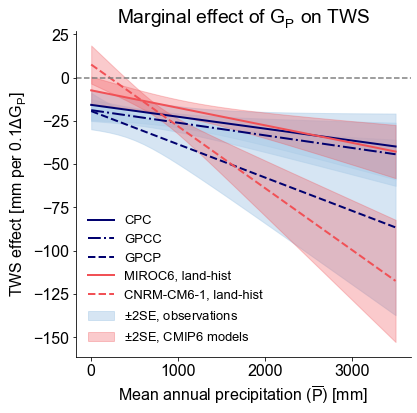

In [51]:
fig = plt.figure(figsize=(6,6))

axs = []
gs = GridSpec(1, 1)

axs.append(fig.add_subplot(gs[0,0]))

col_p = '#01016f'
col_t = '#d8031c'
col_gp = '#c2e4f0'
col_gp1000 = '#aecde8'
col_gp2000 = '#9ac2ed'
col_gp3000 = '#7bb2ed'

##############
ax = axs[0]
# a) conditional gamma
#cpc
l1=ax.plot(x,y,color=col_p,linewidth=2)
s1 = ax.fill_between(x,effecthi,effectlo,color=col_gp1000,alpha=0.5)

#gpcp
l2=ax.plot(x,ygpcp,color=col_p,linewidth=2,linestyle='--')
s2 = ax.fill_between(x,effecthi_gpcp,effectlo_gpcp,color=col_gp1000,alpha=0.5)

#gpcc
l3=ax.plot(x,ygpcc,color=col_p,linewidth=2,linestyle='-.')
s3 = ax.fill_between(x,effecthi_gpcc,effectlo_gpcc,color=col_gp1000,alpha=0.5)

#miroc6
l4=ax.plot(x,y_miroc6,color='#F15156',linewidth=2)
s4 = ax.fill_between(x,effecthi_miroc,effectlo_miroc,color='#F15156',alpha=0.3)

#cnrm
l5=ax.plot(x,y_cnrm,color='#F15156',linestyle='--',linewidth=2)
s5 = ax.fill_between(x,effecthi_cnrm,effectlo_cnrm,color='#F15156',alpha=0.3)


ax.axhline(0,linestyle='--',color='grey')
ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')
ax.set_ylabel('TWS effect [mm per ' +r'$0.1 \Delta{G_P}$]')
#ax.text(0.6,0.8,r'$\frac{\partial {LWE}} {\partial{G_P}} = \gamma + \chi \overline{P}$',transform=ax.transAxes)
ax.set_title(r'Marginal effect of $G_P$ on TWS'  )

#ax.axvline(1000,linestyle='--',color='#a38bbf')
#ax.text(850,-87,'Global mean',fontsize=13,rotation=90)

#legend
lg=ax.legend([l1[0],l3[0],l2[0],l4[0],l5[0],s1,s5],
             ['CPC','GPCC','GPCP','MIROC6, land-hist','CNRM-CM6-1, land-hist',r'$\pm$'+str(n_se) + 'SE, observations',r'$\pm$'+str(n_se) + 'SE, CMIP6 models'],
             loc='lower left',facecolor='white',edgecolor='white',fontsize=13)
lg.get_frame().set_alpha(0)

ax.spines[['right', 'top']].set_visible(False)



In [54]:
plt.savefig(fig_dir+'TWS-effect-obs-CMIP6-land-hist.png')
plt.savefig(fig_dir+'TWS-effect-obs-CMIP6-land-hist.pdf')


<Figure size 864x432 with 0 Axes>

### fluxcom

In [50]:
from ftplib import FTP
ftp = FTP('ftp.bgc-jena.mpg.de')
ftp.login()
ftp.cwd('/outgoing/FluxCom/EnergyFluxes/RS_METEO/ensemble/CERES_GPCP/daily/')
files = []
ftp.retrlines('NLST', files.append)
files[14:28]

['LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2001.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2002.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2003.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2004.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2005.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2006.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2007.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2008.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2009.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2010.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2011.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2012.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2013.nc',
 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2014.nc']

In [ ]:
flux_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/fluxcom/'

import os
os.makedirs(flux_dir, exist_ok=True)
ftp.set_pasv(True)
ftp.cwd('/outgoing/FluxCom/EnergyFluxes/RS_METEO/ensemble/CERES_GPCP/daily/')

# List files
files = []
ftp.retrlines('NLST', files.append)

for fn in files[14:28]:
    print(fn)
    if fn == 'LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2007.nc':
        continue
        
    local = os.path.join(flux_dir, fn)

    # IMPORTANT: switch to binary mode before retrieval
    ftp.voidcmd('TYPE I')

    with open(local, "wb") as f:
        ftp.retrbinary(f"RETR {fn}", f.write)


LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2001.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2002.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2003.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2004.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2005.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2006.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2007.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2008.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2009.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2010.nc
LE.RS_METEO.EBC-ALL.MLM-ALL.METEO-CERES_GPCP.720_360.daily.2011.nc


In [37]:
import xarray as xr

def wyAggF(ds, op='sum'):
    """
    Aggregate a dataset to water years, using NH (Oct–Sep) and SH (Jul–Jun)
    definitions. Operates separately on each hemisphere and merges results.
    
    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with a 'time' and 'lat' dimension.
    op : str
        'sum' or 'mean' — the aggregation operation.

    Returns
    -------
    xarray.Dataset
        Dataset aggregated to water years with coordinate 'water_year'.
    """

    # -------- Assign water-year coordinates --------
    ds = ds.copy()

    # NH: Oct → Sep
    ds = ds.assign_coords(
        water_year_nh = ds.time.dt.year.where(ds.time.dt.month < 10,
                                              ds.time.dt.year + 1)
    )

    # SH: Jul → Jun
    ds = ds.assign_coords(
        water_year_sh = ds.time.dt.year.where(ds.time.dt.month < 7,
                                              ds.time.dt.year + 1)
    )

    # -------- Hemisphere subsets (robust) --------
    nh = ds.where(ds.lat >= 0, drop=True)
    sh = ds.where(ds.lat <  0, drop=True)

    # -------- Water-year aggregation --------
    if op == 'sum':
        nh_wy = nh.groupby('water_year_nh').sum('time', skipna=True)
        sh_wy = sh.groupby('water_year_sh').sum('time', skipna=True)
    elif op == 'mean':
        nh_wy = nh.groupby('water_year_nh').mean('time', skipna=True)
        sh_wy = sh.groupby('water_year_sh').mean('time', skipna=True)
    else:
        raise ValueError("op must be 'sum' or 'mean'")

    # -------- Rename coordinates so they match for merging --------
    nh_wy = nh_wy.rename({'water_year_nh': 'water_year'})
    sh_wy = sh_wy.rename({'water_year_sh': 'water_year'})

    # -------- Merge NH + SH back together --------
    out = xr.combine_by_coords([nh_wy, sh_wy])
    return out



In [20]:
flux_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/fluxcom/'

fc_ds = xr.open_mfdataset(flux_dir+'*.nc',decode_times=False)
fc_ds['time'] = xr.coding.times.decode_cf_datetime(
    fc_ds['time'],
    units="days since 1582-10-15",
    calendar="gregorian"
)

fc_ds = fc_ds *0.408 #MJ/d/m2 to mm
fc_ds = fc_ds.sortby('lat')


In [169]:
fc_wy = wyAgg(fc_ds,op='sum')
fc_wy = flipLon360(fc_wy)

In [170]:
refgrd = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')
fc_wy = fc_wy.interp_like(refgrd.sel(water_year=refgrd.water_year[0]))
    

In [153]:
fc_wy = detrend_dim(fc_wy.LE)

In [172]:
df = pd.read_csv('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/pexq_df_GPCP.csv')
fc_df = fc_wy.to_dataframe().reset_index()
df_merged = df.merge(
    fc_df,
    on=['lon', 'lat', 'water_year'],
    how='left'
)

In [173]:
df_merged.to_csv('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/pexq_df_FLUXCOM-CERES-GPCP_undetrended.csv')

In [130]:
df_merged

,Unnamed: 0,lat,lon,LWE,gridindex,water_year,T,basin_id,yeargrid,Gp_GPCP,Pmean_GPCP,P_GPCP,LE
0,21,-54.25,291.25,-2.986122,-54.25_291.25,2002.0,-0.332735,3403.0,2002_-54.25_291.25,0.048629,572.562922,-294.387449,26.599574
1,22,-54.25,291.75,-2.526054,-54.25_291.75,2002.0,-0.397073,3403.0,2002_-54.25_291.75,0.026312,699.082396,-371.710888,24.416754
2,82,-51.75,288.25,-10.518964,-51.75_288.25,2002.0,0.083794,3220.0,2002_-51.75_288.25,0.014648,544.585340,-222.245932,36.615014
3,83,-51.75,288.75,-10.518964,-51.75_288.75,2002.0,0.033965,3220.0,2002_-51.75_288.75,0.020829,503.671824,-194.617423,33.279839
4,84,-51.75,289.25,-9.551684,-51.75_289.25,2002.0,-0.042306,3220.0,2002_-51.75_289.25,0.024564,488.740404,-190.150264,29.882439
...,...,...,...,...,...,...,...,...,...,...,...,...,...
740830,1092732,69.75,207.25,0.055036,69.75_207.25,2022.0,-8.141871,4110.0,2022_69.75_207.25,-0.016666,253.492813,-53.894235,NaN
740831,1092733,69.75,207.75,0.055036,69.75_207.75,2022.0,-8.188979,4110.0,2022_69.75_207.75,-0.018003,252.543961,-51.512762,NaN
740832,1092734,69.75,208.25,0.055036,69.75_208.25,2022.0,-8.206439,4110.0,2022_69.75_208.25,-0.018365,250.276948,-50.047701,NaN
740833,1092735,69.75,208.75,-0.223448,69.75_208.75,2022.0,-8.225872,4110.0,2022_69.75_208.75,-0.017752,246.691775,-49.499053,NaN


Text(0.5, 1.0, 'Marginal effect of $G_P$ on ET')

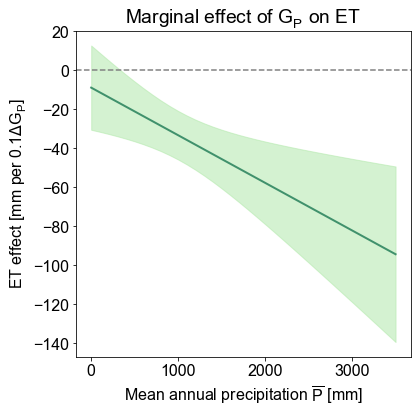

In [3]:
# fluxcom
scale=0.1
n_se = 2
gamma = -89
gamma_se = 108
chi = -0.244
chi_se = 0.087
cov_gamma_chi = -7.68




bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)
yet = scale*gamma+scale*chi*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthiET = yet+scale*n_se*se
effectloET = yet-scale*n_se*se
etshade_col = '#abe7a4'#'#74c69d'
etline_col = '#40916c'

fig,ax = plt.subplots(figsize=(6,6))
l1=ax.plot(x,yet,color=etline_col,linewidth=2)

ax.fill_between(x,effectloET,effecthiET,color=etshade_col,alpha=0.5)

ax.axhline(0,linestyle='--',color='grey')
ax.set_xlabel('Mean annual precipitation '+r'$\overline{P}$ [mm]')
ax.set_ylabel('ET effect [mm per ' +r'$0.1 \Delta{G_P}$]')
#ax.text(0.6,0.8,r'$\frac{\partial {LWE}} {\partial{G_P}} = \gamma + \chi \overline{P}$',transform=ax.transAxes)
ax.set_title(r'Marginal effect of $G_P$ on ET'  )

### water budget closure

In [8]:
flux_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/fluxcom/'

fc_ds = xr.open_mfdataset(flux_dir+'*.nc',decode_times=False)
fc_ds['time'] = xr.coding.times.decode_cf_datetime(
    fc_ds['time'],
    units="days since 1582-10-15",
    calendar="gregorian"
)

fc_ds = fc_ds *0.408 #MJ/d/m2 to mm
fc_ds = fc_ds.sortby('lat')




In [34]:
fc_wy = wyAggF(fc_ds,op='sum')
fc_wy = flipLon360(fc_wy)

In [40]:
gpcp_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCP/v1.3_daily/'

# Get all matching files
files = sorted(glob.glob(gpcp_dir + 'gpcp_*.nc'))

# Keep only files from 2001–2014
years = [str(y) for y in range(2001, 2015)]
files_subset = [f for f in files if any(y in f for y in years)]

# Open only those
gpcp_ds = xr.open_mfdataset(files_subset)

# daily pr -> wy
# harmonize coord names and clear missing
gpcp_ds = gpcp_ds.rename({'longitude':'lon','latitude':'lat'})
gpcp_ds = gpcp_ds.precip.where(gpcp_ds.precip != -99999.0, 0)

In [44]:


#resample to monthly and agg to wy
pr_monthly = gpcp_ds.resample(time='M').sum()
prwy = wyAggF(pr_monthly,'sum')

prwy = prwy.sel(water_year=np.arange(2001,2015))

In [49]:
fc_wy_interp = fc_wy.interp_like(prwy)

In [67]:

# Boolean: ET > P each year
et_gt_p = fc_wy_interp.LE > prwy.precip

# Count number of years ET > P
num_years_et_gt_p = et_gt_p.sum(dim="water_year")

# Optional: convert to integer
num_years_et_gt_p = num_years_et_gt_p.astype(int).compute()

### now plot FLUXCOM ET response alongside budget noncloser map

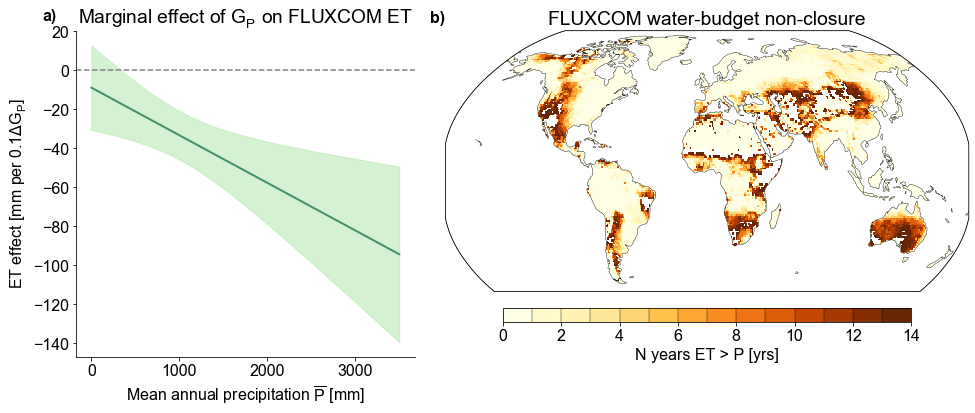

In [84]:
fig = plt.figure(figsize=(16,6),constrained_layout=True)

axs = []
gs = GridSpec(1,5)

axs.append(fig.add_subplot(gs[0,:2]))
axs.append(fig.add_subplot(gs[0,2:],projection=ccrs.Robinson()))


ax = axs[0]
# fluxcom
scale=0.1
n_se = 2
gamma = -89
gamma_se = 108
chi = -0.244
chi_se = 0.087
cov_gamma_chi = -7.68

bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)
yet = scale*gamma+scale*chi*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthiET = yet+scale*n_se*se
effectloET = yet-scale*n_se*se
etshade_col = '#abe7a4'#'#74c69d'
etline_col = '#40916c'

l1=ax.plot(x,yet,color=etline_col,linewidth=2)

ax.fill_between(x,effectloET,effecthiET,color=etshade_col,alpha=0.5)

ax.axhline(0,linestyle='--',color='grey')
ax.set_xlabel('Mean annual precipitation '+r'$\overline{P}$ [mm]')
ax.set_ylabel('ET effect [mm per ' +r'$0.1 \Delta{G_P}$]')
#ax.text(0.6,0.8,r'$\frac{\partial {LWE}} {\partial{G_P}} = \gamma + \chi \overline{P}$',transform=ax.transAxes)
ax.set_title(r'Marginal effect of $G_P$ on FLUXCOM ET'  )

ax.spines[['right', 'top']].set_visible(False)
ax.text(-0.1,1.03,'a)',transform=ax.transAxes,fontweight='bold')

### b)
ax = axs[1]
ax.set_aspect('auto')
vmin = 0
vmax = 14
bounds = np.arange(vmin,vmax+.1, 1)  
cmap = plt.get_cmap("YlOrBr", len(bounds) - 1)  # Must match len(bounds) - 1
norm = matplotlib.colors.BoundaryNorm(boundaries=bounds, ncolors=len(bounds) - 1, clip=False)

lab = 'N years ET > P [yrs]'

num_years_et_gt_p.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmap,norm=norm,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.78,
                                                      'aspect':30,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})

ax.set_extent((-180,180,-60,90), crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 

ax.set_title('FLUXCOM water-budget non-closure')

ax.text(-0.03,1.03,'b)',transform=ax.transAxes,fontweight='bold')

plt.tight_layout()